# Explorative Analyse: Arbeitsmarkt Regensburg (Jobcenter)

**Datenquelle:** Statistik der Bundesagentur für Arbeit, Bericht *"Eckwerte für Jobcenter"*, Jobcenter Regensburg
(Statistik-Nr. t73906-0), monatliche Excel-Berichte aus `Data/RegensburgJCData/`.

**Zeitraum:** April 2025 – Juni 2026 (15 Berichtsmonate, ein `.xlsx` je Monat).

Jeder Bericht enthält u. a. ein Tabellenblatt **"1.1 Eckwerte"** mit dem aktuellen Monatswert je Merkmal,
getrennt nach *"Insgesamt (SGB II und SGB III)"* und *"Rechtskreis SGB II"* (= Jobcenter-Zuständigkeit).
Diese Analyse extrahiert aus allen 15 Dateien die SGB-II-Werte und baut daraus eine Zeitreihe.

In [1]:
import glob
import re
from pathlib import Path

import matplotlib.pyplot as plt
import openpyxl
import pandas as pd

DATA_DIR = Path("..") / "Data" / "RegensburgJCData"

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Daten einlesen

Alle Monatsberichte parsen und in ein *tidy* DataFrame (`period`, `kategorie`, `merkmal`, `insgesamt`, `sgb2`) überführen.

In [2]:
def normalize_label(label: str) -> str:
    """Entfernt Fußnotenmarker wie ' 1)' oder ' 2) 4)' aus Zeilenbeschriftungen."""
    return re.sub(r"\s*\d\)", "", label).strip()


def parse_eckwerte(path: Path) -> list[dict]:
    """Liest das Blatt '1.1 Eckwerte' eines Monatsberichts aus.

    Spalte B enthält den Wert 'Insgesamt (SGB II und SGB III)', Spalte G den
    Wert für den 'Rechtskreis SGB II' (= Jobcenter) im aktuellen Berichtsmonat.
    Zeilen ohne Zahlwert sind Kategorie-Überschriften (z.B. 'Arbeitslose').
    """
    match = re.search(r"(\d{6})-xlsx\.xlsx$", path.name)
    period = pd.Period(match.group(1), freq="M")

    wb = openpyxl.load_workbook(path, data_only=True)
    ws = wb["1.1 Eckwerte"]

    records = []
    category = None
    for row in range(9, 45):
        label = ws.cell(row=row, column=1).value
        insgesamt = ws.cell(row=row, column=2).value
        sgb2 = ws.cell(row=row, column=7).value

        if not isinstance(label, str) or not label.strip():
            continue
        label = normalize_label(label)

        is_value_row = isinstance(insgesamt, (int, float)) or isinstance(sgb2, (int, float))
        if not is_value_row:
            category = label
            continue

        records.append({
            "period": period,
            "kategorie": category,
            "merkmal": label,
            "insgesamt": insgesamt,
            "sgb2": sgb2,
        })
    return records


files = sorted(DATA_DIR.glob("*.xlsx"))
print(f"{len(files)} Berichte gefunden: {files[0].name} ... {files[-1].name}")

all_records = [rec for f in files for rec in parse_eckwerte(f)]
df = pd.DataFrame(all_records).sort_values(["period", "kategorie", "merkmal"]).reset_index(drop=True)
df.head(10)

15 Berichte gefunden: jc-eckwerte-t73906-0-202504-xlsx.xlsx ... jc-eckwerte-t73906-0-202606-xlsx.xlsx


C:\Users\funke\AppData\Roaming\Python\Python314\site-packages\openpyxl\reader\drawings.py:33: UserWarning: DrawingML support is incomplete and limited to charts and images only. Shapes and drawings will be lost.
  warn("DrawingML support is incomplete and limited to charts and images only. Shapes and drawings will be lost.")
C:\Users\funke\AppData\Roaming\Python\Python314\site-packages\openpyxl\reader\drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


,period,kategorie,merkmal,insgesamt,sgb2
0,2025-04,Arbeitslose,15 bis unter 25 Jahre,355.0,160.0
1,2025-04,Arbeitslose,25 bis unter 50 Jahre,1833.0,854.0
2,2025-04,Arbeitslose,50 Jahre und älter,1306.0,443.0
3,2025-04,Arbeitslose,55 Jahre und älter,1008.0,302.0
4,2025-04,Arbeitslose,Abgang (12-Monatssumme),9024.0,3348.0
5,2025-04,Arbeitslose,Abgang (im Monat),864.0,250.0
6,2025-04,Arbeitslose,Arbeitslosenquote,3.0,1.3
7,2025-04,Arbeitslose,Ausländer,1216.0,735.0
8,2025-04,Arbeitslose,Bestand,3494.0,1457.0
9,2025-04,Arbeitslose,Frauen,1507.0,667.0


## 2. Datenüberblick

In [3]:
print("Shape:", df.shape)
print("Berichtsmonate:", df['period'].min(), "-", df['period'].max(), f"({df['period'].nunique()} Monate)")
print("\nMerkmale je Kategorie:")
for kat, sub in df.groupby("kategorie", sort=False):
    print(f"- {kat}: {sorted(sub['merkmal'].unique())}")
print("\nFehlende Werte (sgb2):", df['sgb2'].isna().sum())

Shape: (420, 5)
Berichtsmonate: 2025-04 - 2026-06 (15 Monate)

Merkmale je Kategorie:
- Arbeitslose: ['15 bis unter 25 Jahre', '25 bis unter 50 Jahre', '50 Jahre und älter', '55 Jahre und älter', 'Abgang (12-Monatssumme)', 'Abgang (im Monat)', 'Arbeitslosenquote', 'Ausländer', 'Bestand', 'Frauen', 'Langzeitarbeitslose', 'Männer', 'Zugang (12-Monatssumme)', 'Zugang (im Monat)', 'schwerbehinderte Menschen']
- Arbeitsuchende: ['Bestand']
- Grundsicherung für Arbeitsuchende: ['Bedarfsgemeinschaften (BG)', 'Personen in Bedarfsgemeinschaften (PERS)']
- Unterbeschäftigung: ['Arbeitslosigkeit im weiteren Sinne', 'Unterbeschäftigung (ohne Kurzarbeit)', 'Unterbeschäftigung im engeren Sinne', 'Unterbeschäftigungsquote']
- gemeldete Arbeitsstellen: ['Bestand', 'Zugang (12-Monatssumme)', 'Zugang (im Monat)', 'sozialversicherungspflichtig']

Fehlende Werte (sgb2): 90


In [4]:
def sgb2_series(kategorie_prefix: str, merkmal: str) -> pd.Series:
    sub = df[df["kategorie"].str.startswith(kategorie_prefix) & (df["merkmal"] == merkmal)]
    return sub.set_index(sub["period"].dt.to_timestamp())["sgb2"].sort_index()


bestand = sgb2_series("Arbeitslose", "Bestand")
quote = sgb2_series("Arbeitslose", "Arbeitslosenquote")
lza = sgb2_series("Arbeitslose", "Langzeitarbeitslose")
uq = sgb2_series("Unterbeschäftigung", "Unterbeschäftigungsquote")
uws = sgb2_series("Unterbeschäftigung", "Arbeitslosigkeit im weiteren Sinne")
bg = sgb2_series("Grundsicherung", "Bedarfsgemeinschaften (BG)")
pers = sgb2_series("Grundsicherung", "Personen in Bedarfsgemeinschaften (PERS)")

kennzahlen = pd.DataFrame({
    "Arbeitslose (Bestand)": bestand,
    "Arbeitslosenquote (%)": quote,
    "Langzeitarbeitslose": lza,
    "Unterbeschäftigungsquote (%)": uq,
    "Bedarfsgemeinschaften": bg,
    "Personen in BG": pers,
})
kennzahlen

,Arbeitslose (Bestand),Arbeitslosenquote (%),Langzeitarbeitslose,Unterbeschäftigungsquote (%),Bedarfsgemeinschaften,Personen in BG
period,,,,,,
2025-04-01,1457.0,1.3,526.0,1.8,2766.959069,5421.148834
2025-05-01,1438.0,1.2,558.0,1.8,2707.556182,5295.629265
2025-06-01,1509.0,1.3,551.0,1.8,2696.605759,5275.539536
2025-07-01,1475.0,1.3,561.0,1.8,2616.920054,5092.808598
2025-08-01,1587.0,1.4,585.0,1.8,2688.060659,5267.867812
2025-09-01,1585.0,1.4,592.0,1.8,2669.283813,5218.350099
2025-10-01,1519.0,1.3,606.0,1.7,2629.348039,5120.198766
2025-11-01,1517.0,1.3,623.0,1.7,2632.776815,5126.678771
2025-12-01,1466.0,1.3,610.0,1.7,2619.193501,5137.270730


## 3. Entwicklung der Arbeitslosigkeit (SGB II)

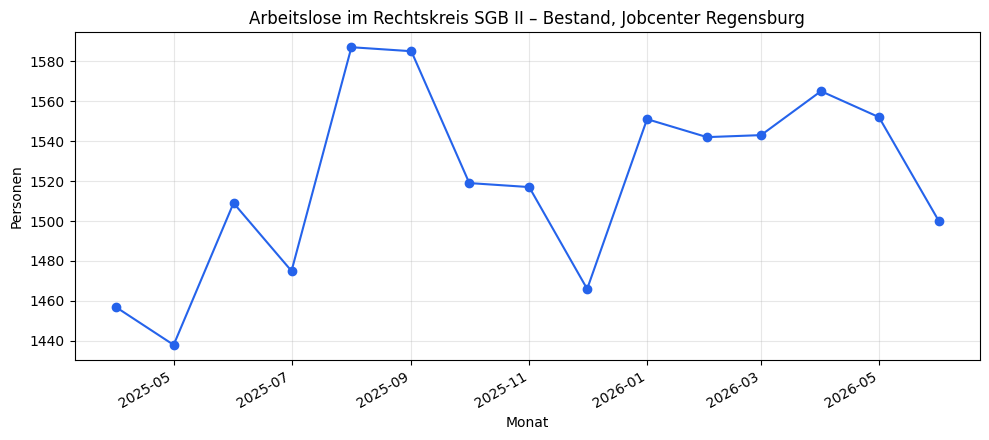

In [5]:
fig, ax = plt.subplots()
ax.plot(bestand.index, bestand.values, marker="o", color="#2563eb")
ax.set_title("Arbeitslose im Rechtskreis SGB II – Bestand, Jobcenter Regensburg")
ax.set_ylabel("Personen")
ax.set_xlabel("Monat")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

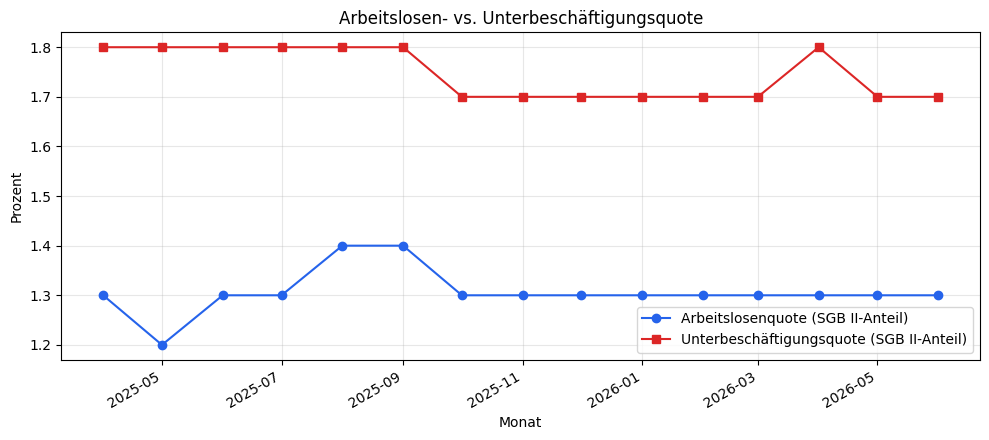

In [6]:
fig, ax = plt.subplots()
ax.plot(quote.index, quote.values, marker="o", label="Arbeitslosenquote (SGB II-Anteil)", color="#2563eb")
ax.plot(uq.index, uq.values, marker="s", label="Unterbeschäftigungsquote (SGB II-Anteil)", color="#dc2626")
ax.set_title("Arbeitslosen- vs. Unterbeschäftigungsquote")
ax.set_ylabel("Prozent")
ax.set_xlabel("Monat")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 4. Langzeitarbeitslosigkeit

Anteil der Langzeitarbeitslosen (≥ 1 Jahr arbeitslos) am gesamten Bestand der Arbeitslosen im SGB II.

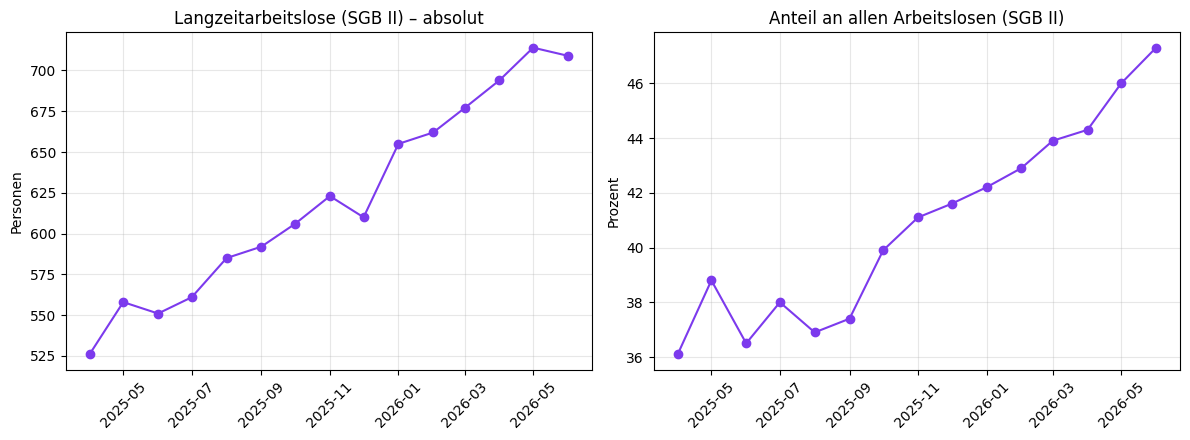

Langzeitarbeitslose: 526 (Apr 2025) -> 709 (Jun 2026)
Anteil am Bestand: 36.1% -> 47.3%


In [7]:
lza_anteil = (lza / bestand * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(lza.index, lza.values, marker="o", color="#7c3aed")
ax1.set_title("Langzeitarbeitslose (SGB II) – absolut")
ax1.set_ylabel("Personen")
ax1.tick_params(axis="x", rotation=45)

ax2.plot(lza_anteil.index, lza_anteil.values, marker="o", color="#7c3aed")
ax2.set_title("Anteil an allen Arbeitslosen (SGB II)")
ax2.set_ylabel("Prozent")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Langzeitarbeitslose: {lza.iloc[0]:.0f} ({lza.index[0]:%b %Y}) -> {lza.iloc[-1]:.0f} ({lza.index[-1]:%b %Y})")
print(f"Anteil am Bestand: {lza_anteil.iloc[0]:.1f}% -> {lza_anteil.iloc[-1]:.1f}%")

## 5. Grundsicherung: Bedarfsgemeinschaften und Personen im Leistungsbezug

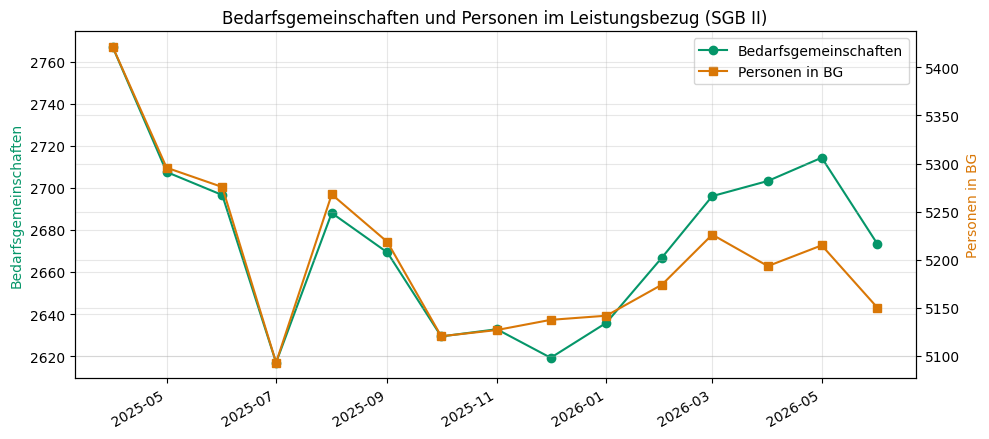

In [8]:
fig, ax = plt.subplots()
ax.plot(bg.index, bg.values, marker="o", label="Bedarfsgemeinschaften", color="#059669")
ax2 = ax.twinx()
ax2.plot(pers.index, pers.values, marker="s", label="Personen in BG", color="#d97706")

ax.set_title("Bedarfsgemeinschaften und Personen im Leistungsbezug (SGB II)")
ax.set_ylabel("Bedarfsgemeinschaften", color="#059669")
ax2.set_ylabel("Personen in BG", color="#d97706")
fig.autofmt_xdate()

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

## 6. Altersstruktur und Geschlecht (letzter Berichtsmonat)

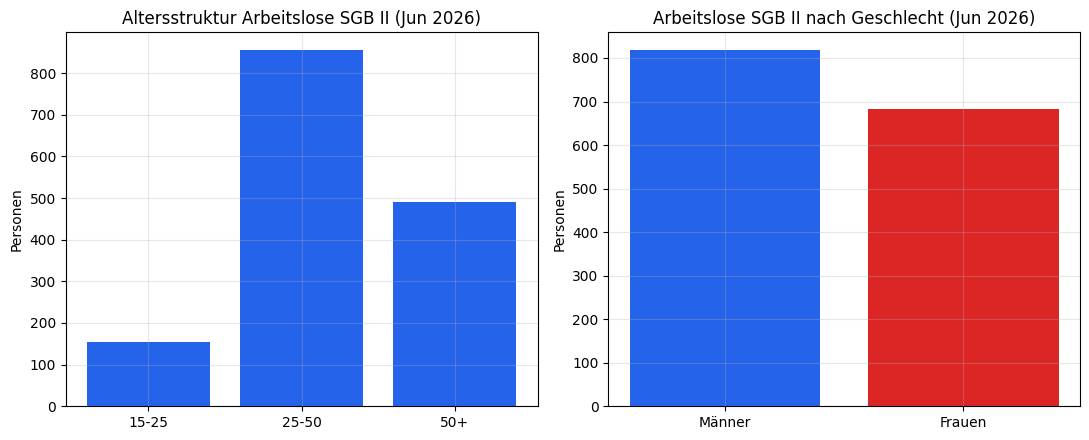

In [9]:
letzter_monat = df["period"].max()
letzter_monat_label = letzter_monat.strftime("%b %Y")
snap = df[(df["period"] == letzter_monat) & (df["kategorie"] == "Arbeitslose")]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

alter_labels = ["15 bis unter 25 Jahre", "25 bis unter 50 Jahre", "50 Jahre und älter"]
alter_werte = [snap.set_index("merkmal").loc[l, "sgb2"] for l in alter_labels]
ax1.bar(["15-25", "25-50", "50+"], alter_werte, color="#2563eb")
ax1.set_title(f"Altersstruktur Arbeitslose SGB II ({letzter_monat_label})")
ax1.set_ylabel("Personen")

geschlecht_labels = ["Männer", "Frauen"]
geschlecht_werte = [snap.set_index("merkmal").loc[l, "sgb2"] for l in geschlecht_labels]
ax2.bar(geschlecht_labels, geschlecht_werte, color=["#2563eb", "#dc2626"])
ax2.set_title(f"Arbeitslose SGB II nach Geschlecht ({letzter_monat_label})")
ax2.set_ylabel("Personen")

plt.tight_layout()
plt.show()

## 7. Veränderung zum Vormonat und zum Vorjahresmonat

In [10]:
def veraenderung(series: pd.Series) -> pd.DataFrame:
    letzter = series.iloc[-1]
    vormonat = series.iloc[-2]
    vorjahr = series.iloc[-13] if len(series) >= 13 else None
    return pd.Series({
        "aktuell": letzter,
        "Vormonat abs.": letzter - vormonat,
        "Vormonat %": round((letzter - vormonat) / vormonat * 100, 1),
        "Vorjahresmonat abs.": (letzter - vorjahr) if vorjahr is not None else None,
        "Vorjahresmonat %": round((letzter - vorjahr) / vorjahr * 100, 1) if vorjahr is not None else None,
    })


changes = pd.DataFrame({
    "Arbeitslose (Bestand)": veraenderung(bestand),
    "Langzeitarbeitslose": veraenderung(lza),
    "Bedarfsgemeinschaften": veraenderung(bg),
    "Personen in BG": veraenderung(pers),
}).T
changes

,aktuell,Vormonat abs.,Vormonat %,Vorjahresmonat abs.,Vorjahresmonat %
Arbeitslose (Bestand),1500.000000,-52.000000,-3.4,-9.000000,-0.6
Langzeitarbeitslose,709.000000,-5.000000,-0.7,158.000000,28.7
Bedarfsgemeinschaften,2673.353373,-41.012939,-1.5,-23.252386,-0.9
Personen in BG,5149.986005,-64.836537,-1.2,-125.553531,-2.4


## 8. Zusammenfassung

Auf Basis der 15 Monatsberichte (April 2025 – Juni 2026) für das Jobcenter Regensburg (Rechtskreis SGB II):

- **Arbeitslose (Bestand):** von 1.457 (Apr 2025) auf 1.500 (Jun 2026) – leicht gestiegen, mit einem
  Zwischenhoch von 1.587 im August 2025 und einem Tiefpunkt von 1.438 im Mai 2025.
- **Arbeitslosenquote:** schwankt eng zwischen 1,2 % und 1,4 %, aktuell wieder bei 1,3 % – insgesamt stabil.
- **Langzeitarbeitslosigkeit:** deutlichster Trend im Datensatz – von 526 auf 709 Personen (+ rund 35 %),
  mit einem Höchststand von 714 im Mai 2026. Der Anteil an allen Arbeitslosen ist damit spürbar gestiegen.
- **Bedarfsgemeinschaften / Personen im Leistungsbezug:** beide Kennzahlen sind rückläufig
  (BG: 2.767 → 2.673; Personen in BG: 5.421 → 5.150, jeweils ca. −5 %).

**Interpretation:** Während die reine Arbeitslosenzahl und -quote im Beobachtungszeitraum relativ stabil
geblieben sind, hat sich die Langzeitarbeitslosigkeit spürbar verschärft – ein Hinweis darauf, dass es für
einen wachsenden Teil der Betroffenen schwerer wird, aus der Arbeitslosigkeit herauszukommen, auch wenn die
Zahl der Bedarfsgemeinschaften insgesamt sinkt.